# 03 · Model Comparisons (cpsam vs cyto3 vs bact_fluor_cp3 vs Omnipose)

Loads all saved baseline mask files and produces the final comparison figure.

**Environment:** `cellpose`
**Run after:**
1. `02_cellpose_baseline.ipynb` — generates cpsam masks and the shared input patch
2. `scripts/run_cellpose3_baseline.py` (in a Cellpose 3.x env) — generates cyto3 and bact_fluor_cp3 masks
3. `scripts/run_omnipose_baseline.py` (in `omnipose` env) — generates Omnipose masks

**Outputs:**
- `figures/qc/model_comparison_baseline.png`
- `figures/qc/model_comparison_cell_sizes.png`

In [28]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.measure import regionprops

## Load all results

In [29]:
PROJECT_ROOT = Path('/Users/alicehong/projects/cellpose-biosensor')

(PROJECT_ROOT / 'figures/qc').mkdir(parents=True, exist_ok=True)

crop_raw    = tifffile.imread(PROJECT_ROOT / 'data/processed/comparison_patch_bfp.tif').astype(float)
masks_cpsam = tifffile.imread(PROJECT_ROOT / 'data/processed/masks_cpsam.tif').astype(int)

def load_optional_mask(path, label):
    path = PROJECT_ROOT / path
    if path.exists():
        print(f'{label} masks loaded.')
        return tifffile.imread(str(path)).astype(int), True
    print(f'WARNING: {path.name} not found — run scripts/run_cellpose3_baseline.py '
          'in a Cellpose 3.x env first.')
    return np.zeros_like(masks_cpsam), False

masks_cyto3, have_cyto3 = load_optional_mask('data/processed/masks_cyto3.tif', 'cyto3')
masks_bact_cp3, have_bact_cp3 = load_optional_mask(
    'data/processed/masks_bact_fluor_cp3.tif', 'bact_fluor_cp3')

omnipose_path = PROJECT_ROOT / 'data/processed/masks_bact_fluor_omni.tif'
legacy_omnipose_path = PROJECT_ROOT / 'data/processed/masks_omnipose.tif'
if not omnipose_path.exists() and legacy_omnipose_path.exists():
    omnipose_path = legacy_omnipose_path
if omnipose_path.exists():
    masks_omni = tifffile.imread(str(omnipose_path)).astype(int)
    have_omni  = True
    print('Omnipose masks loaded.')
else:
    masks_omni = np.zeros_like(masks_cpsam)
    have_omni  = False
    print('WARNING: masks_bact_fluor_omni.tif not found — '
          'run scripts/run_omnipose_baseline.py in the omnipose env first.')

print(f'Patch size: {crop_raw.shape}')

# Normalise for display
lo = np.percentile(crop_raw, 1)
hi = np.percentile(crop_raw, 99.9)
crop_norm = np.clip((crop_raw - lo) / max(hi - lo, 1), 0, 1)

# Downsample for display — patch is ~2100×2100, 1:4 ≈ 525×525
THUMB = 4
thumb_norm = crop_norm[::THUMB, ::THUMB]

cyto3 masks loaded.
bact_fluor_cp3 masks loaded.
Omnipose masks loaded.
Patch size: (1581, 1586)


## Per-cell size distributions

In [30]:
def cell_areas(masks):
    return [r.area for r in regionprops(masks)]

areas_cpsam = cell_areas(masks_cpsam)
areas_cyto3 = cell_areas(masks_cyto3)
areas_bact_cp3 = cell_areas(masks_bact_cp3)
areas_omni  = cell_areas(masks_omni) if have_omni else []

print(f'{"Model":<18} {"N cells":>8} {"Median area (px²)":>18} {"Mean area (px²)":>16}')
print('-' * 64)
for name, areas in [
    ('cpsam', areas_cpsam),
    ('cyto3', areas_cyto3),
    ('bact_fluor_cp3', areas_bact_cp3),
    ('bact_fluor_omni', areas_omni),
]:
    if areas:
        print(f'{name:<18} {len(areas):>8} '
              f'{np.median(areas):>18.1f} {np.mean(areas):>16.1f}')
    else:
        print(f'{name:<18} {"—":>8}')

Model               N cells  Median area (px²)  Mean area (px²)
----------------------------------------------------------------
cpsam                    33              913.0           2081.9
cyto3                    41             1035.0           2018.5
bact_fluor_cp3           40              819.5            937.5
bact_fluor_omni          86              638.5            892.4


## Mask overlay comparison

Row 1: contour overlays on BFP image.
Row 2: raw label maps (each cell a unique colour).

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/qc/model_comparison_baseline2.svg


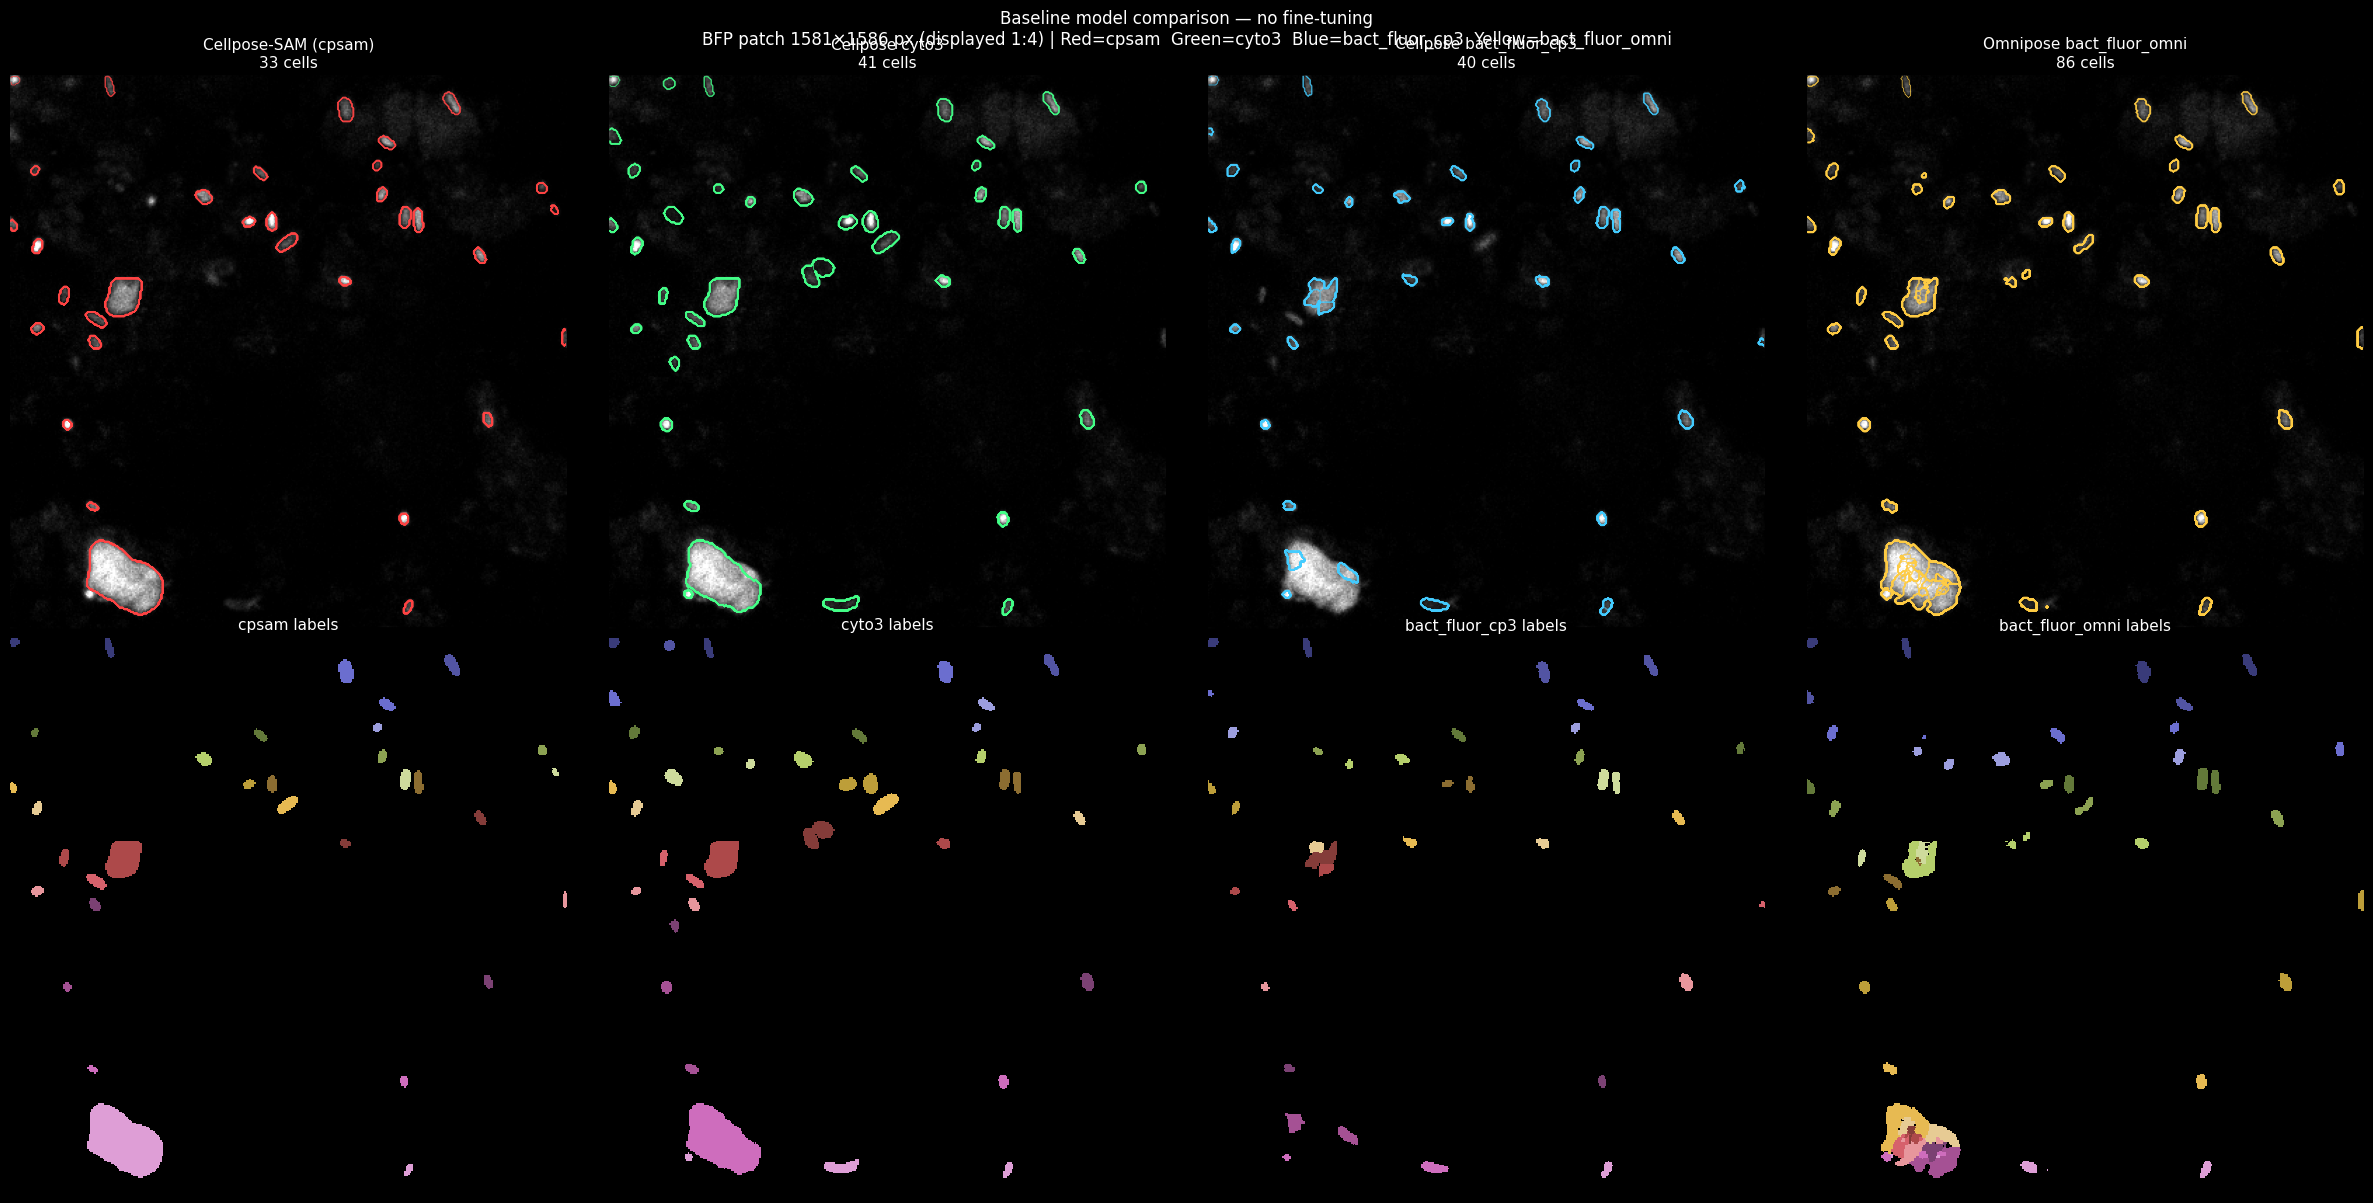

In [35]:
def label_cmap():
    cmap = plt.colormaps['tab20b'].copy()
    cmap.set_under('black')  # label 0/background
    return cmap

MASK_CMAP = label_cmap()

def draw_panel(ax, img_thumb, masks, title, color='red'):
    masks_thumb = masks[::THUMB, ::THUMB]
    ax.set_facecolor('black')
    ax.imshow(img_thumb, cmap='gray', vmin=0, vmax=1)
    if masks_thumb.max() > 0:
        ax.contour(masks_thumb, levels=np.arange(0.5, masks_thumb.max() + 0.5),
                   colors=color, linewidths=0.5)
    ax.set_title(f'{title}\n{masks.max()} cells', color='white', fontsize=11, pad=6)
    ax.axis('off')

fig, axes = plt.subplots(2, 4, figsize=(24, 12), facecolor='black')

draw_panel(axes[0][0], thumb_norm, masks_cpsam,    'Cellpose-SAM (cpsam)',  '#ff4444')
draw_panel(axes[0][1], thumb_norm, masks_cyto3,    'Cellpose cyto3',        '#44ff88')
draw_panel(axes[0][2], thumb_norm, masks_bact_cp3, 'Cellpose bact_fluor_cp3', '#44ccff')
if have_omni:
    draw_panel(axes[0][3], thumb_norm, masks_omni, 'Omnipose bact_fluor_omni', '#ffcc44')
else:
    axes[0][3].set_facecolor('black')
    axes[0][3].imshow(thumb_norm, cmap='gray', vmin=0, vmax=1)
    axes[0][3].set_title('Omnipose bact_fluor_omni\n(not yet run)', color='yellow', fontsize=11)
    axes[0][3].axis('off')

for ax, masks, title in zip(axes[1],
                             [masks_cpsam, masks_cyto3, masks_bact_cp3, masks_omni],
                             ['cpsam labels', 'cyto3 labels', 'bact_fluor_cp3 labels', 'bact_fluor_omni labels']):
    ax.set_facecolor('black')
    ax.imshow(masks[::THUMB, ::THUMB], cmap=MASK_CMAP, vmin=0.5, interpolation='nearest')
    ax.set_title(title, color='white', fontsize=11)
    ax.axis('off')

if not have_omni:
    axes[1][3].set_facecolor('black')
    axes[1][3].text(0.5, 0.5, 'Run omnipose script first',
                    ha='center', va='center', color='yellow',
                    transform=axes[1][3].transAxes, fontsize=12)
    axes[1][3].axis('off')

fig.suptitle(f'Baseline model comparison — no fine-tuning\n'
             f'BFP patch {crop_raw.shape[0]}×{crop_raw.shape[1]} px (displayed 1:{THUMB}) | '
             f'Red=cpsam  Green=cyto3  Blue=bact_fluor_cp3  Yellow=bact_fluor_omni',
             color='white', fontsize=12, y=0.99)
plt.tight_layout(pad=0.3)
plt.savefig(PROJECT_ROOT / 'figures/qc/model_comparison_baseline2.svg', # change number!!!
            dpi=150, bbox_inches='tight', facecolor='black')
print(f'Saved → {PROJECT_ROOT}/figures/qc/model_comparison_baseline2.svg')
plt.show()

## Cell area histograms

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/qc/model_comparison_cell_sizes.png


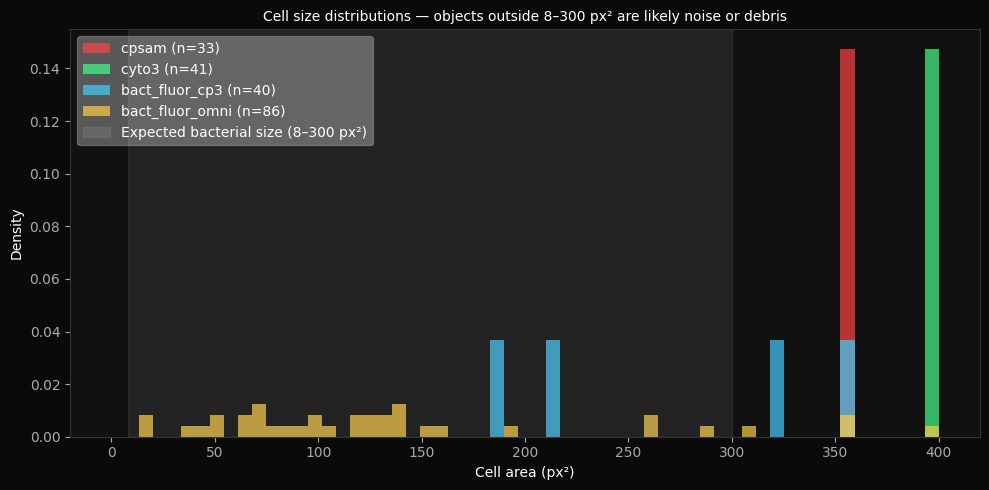

In [32]:
fig2, ax = plt.subplots(figsize=(10, 5), facecolor='#0a0a0a')
ax.set_facecolor('#111111')
bins = np.linspace(0, 400, 60)

if areas_cpsam:
    ax.hist(areas_cpsam, bins=bins, alpha=0.7, color='#ff4444',
            label=f'cpsam (n={len(areas_cpsam)})', density=True)
if areas_cyto3:
    ax.hist(areas_cyto3, bins=bins, alpha=0.7, color='#44ff88',
            label=f'cyto3 (n={len(areas_cyto3)})', density=True)
if areas_bact_cp3:
    ax.hist(areas_bact_cp3, bins=bins, alpha=0.7, color='#44ccff',
            label=f'bact_fluor_cp3 (n={len(areas_bact_cp3)})', density=True)
if areas_omni:
    ax.hist(areas_omni, bins=bins, alpha=0.7, color='#ffcc44',
            label=f'bact_fluor_omni (n={len(areas_omni)})', density=True)

ax.axvspan(8, 300, alpha=0.08, color='white',
           label='Expected bacterial size (8–300 px²)')
ax.set_xlabel('Cell area (px²)', color='white')
ax.set_ylabel('Density', color='white')
ax.set_title('Cell size distributions — objects outside 8–300 px² are likely noise or debris',
             color='white', fontsize=10)
ax.legend(framealpha=0.3, labelcolor='white')
ax.tick_params(colors='#aaaaaa')
for sp in ax.spines.values(): sp.set_edgecolor('#333333')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures/qc/model_comparison_cell_sizes.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
print(f'Saved → {PROJECT_ROOT}/figures/qc/model_comparison_cell_sizes.png')
plt.show()